<a href="https://colab.research.google.com/github/adikatre/Asymmetric-Cross-Modal-Attention/blob/main/notebooks/02_train_evaluate_visualize_colab_frozen_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load and Unzip VQA Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

!rm -rf /content/sample_data/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Get vqa data from drive opt.
!cp "/content/drive/MyDrive/VQA.zip" "/content/"

In [6]:
# make data dirs
!mkdir -p /content/data/
!mkdir -p /content/data/answers
!mkdir -p /content/data/images
!mkdir -p /content/data/questions

#copy over zips (https://drive.google.com/drive/folders/1VJ1xNxo_dAGJ4ZcpaFQBo-wpdIChZkpx?usp=sharing) from drive into here
!cp -r /content/drive/MyDrive/VQA/* /content/data/zip/

In [ ]:
# unqip vqa.zip, then remove it opt.
!unzip -q /content/VQA.zip -d /content/data/zip

!rm -rf /content/VQA.zip

In [ ]:
# test2015 opt.
!unzip -q /content/data/zip/test2015.zip -d /content/data/images/

!rm -rf /content/data/zip/test2015.zip

In [ ]:
# train2014 opt.
!unzip -q /content/data/zip/train2014.zip -d /content/data/images/

!rm -rf /content/data/zip/train2014.zip

In [ ]:
# val2014 opt.
!unzip -q /content/data/zip/val2014.zip -d /content/data/images/

!rm -rf /content/data/zip/val2014.zip

In [7]:
# extract annotations (labels)
!unzip -q /content/data/zip/v2_Annotations_Train_mscoco.zip -d /content/data/answers/
!unzip -q /content/data/zip/v2_Annotations_Val_mscoco.zip -d /content/data/answers/

!rm -rf /content/data/zip/v2_Annotations_Train_mscoco.zip
!rm -rf /content/data/zip/v2_Annotations_Val_mscoco.zip

In [8]:
# extract testing data
!unzip -q /content/data/zip/v2_Questions_Test_mscoco.zip -d /content/data/questions/
!unzip -q /content/data/zip/v2_Questions_Train_mscoco.zip -d /content/data/questions/
!unzip -q /content/data/zip/v2_Questions_Val_mscoco.zip -d /content/data/questions/

!rm -rf /content/data/zip/v2_Questions_Test_mscoco.zip
!rm -rf /content/data/zip/v2_Questions_Train_mscoco.zip
!rm -rf /content/data/zip/v2_Questions_Val_mscoco.zip

In [9]:
# move vqa_images.h5 to /data
!mv /content/data/zip/vqa_images.h5 /content/data/

# 2 — Train, Evaluate & Visualize

Complete experiment in one notebook:

1. **Data** — Load VQA v2.0 dataset
2. **Models** — Define encoders, attention blocks, and full VQA models
3. **Training** — Train symmetric baseline and asymmetric model
4. **Evaluation** — Compare metrics (Top-1, Top-5 accuracy)
5. **Visualization** — Training curves, attention heatmaps, qualitative examples

**Run all cells in order.** Edit the configuration cell below to change hyperparameters.

In [10]:
!pip install -q torch torchvision transformers matplotlib tqdm Pillow

In [11]:
import json
import random
import time
from collections import Counter
from contextlib import nullcontext
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ViT_B_16_Weights, vit_b_16
from tqdm import tqdm
from transformers import RobertaModel, RobertaTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Configuration

Edit these variables to change the experiment.

In [12]:
# Paths
DATA_DIR       = Path("/content/data")
CHECKPOINT_DIR = Path("/content/results/checkpoints")
METRICS_DIR    = Path("/content/results/metrics")
FIGURES_DIR    = Path("/content/results/figures")

# Model
NUM_ANSWERS      = 1000
EMBED_DIM        = 512
NUM_HEADS        = 8
DROPOUT          = 0.2 # changed from .3 to avoid overfitting to yes/no questions
FREEZE_ENCODERS  = True # Change to False later to compare performance with freezed vs. unfreezed
# Note: FREEZE_ENCODERS may be broken due to offline generation of encoders

# Data
MAX_QUESTION_LEN = 20
MAX_SAMPLES      = None    # set to 1000 for a quick dev run, and None for a complete run

# Training
BATCH_SIZE       = 128 # gpu was underutilized. changed from 64 to 128
LEARNING_RATE    = 1e-4
WEIGHT_DECAY     = 1e-5
EPOCHS           = 18 # was initially 20; changed due to minimal gains during higher epochs
NUM_WORKERS      = 4
SEED             = 42
USE_AMP          = True

for d in [CHECKPOINT_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

---
## 1. Data Loading

In [13]:
def build_answer_vocab(annotations_file, top_k=1000):
    """Build answer vocabulary from the top_k most frequent answers."""
    with open(annotations_file) as f:
        annotations = json.load(f)["annotations"]

    counter = Counter()
    for ann in annotations:
        counter[ann["multiple_choice_answer"]] += 1

    most_common = [ans for ans, _ in counter.most_common(top_k)]
    answer_to_idx = {ans: idx for idx, ans in enumerate(most_common)}
    idx_to_answer = {idx: ans for ans, idx in answer_to_idx.items()}
    return answer_to_idx, idx_to_answer


def get_image_transform(split="train"):
    """ImageNet-normalised transform for ViT-B/16 (224x224)."""
    if split == "train":
        return transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_h5_preprocess_transform():
    """Resize to 256x256 for HDF5 storage (no normalization, no crop randomness)."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
    ])

## Storage as one .h5 file

resized to 256x256 before adding to .h5 file

In [14]:
# --- HDF5 Preprocessing: convert raw JPEGs into a single contiguous file ---
h5_path = DATA_DIR / "vqa_images.h5"

if not h5_path.exists():
    preprocess = get_h5_preprocess_transform()
    image_dirs = [DATA_DIR / "images" / "train2014", DATA_DIR / "images" / "val2014"]

    # Collect all image paths
    all_paths = []
    for d in image_dirs:
        if d.exists():
            all_paths.extend(sorted(d.glob("*.jpg")))
    print(f"Found {len(all_paths):,} images to preprocess")

    with h5py.File(h5_path, "w") as h5f:
        imgs_ds = h5f.create_dataset(
            "images", shape=(len(all_paths), 256, 256, 3),
            dtype=np.uint8, chunks=(1, 256, 256, 3))
        ids_ds = h5f.create_dataset(
            "image_ids", shape=(len(all_paths),), dtype=np.int64)

        for i, path in enumerate(tqdm(all_paths, desc="Preprocessing images")):
            image_id = int(path.stem.split("_")[-1])
            img = Image.open(path).convert("RGB")
            img = preprocess(img)
            imgs_ds[i] = np.array(img)
            ids_ds[i] = image_id

    print(f"Saved {len(all_paths):,} images to {h5_path}")
else:
    print(f"HDF5 file already exists: {h5_path}")

HDF5 file already exists: /content/data/vqa_images.h5


In [15]:
class VQADataset(Dataset):
    """PyTorch dataset for VQA v2.0 with HDF5 image loading and soft targets.

    Returns (image_tensor, input_ids, attention_mask, answer_target) tuples.
    answer_target is a soft probability vector of shape (num_answers,) built
    from all 10 annotator answers.
    """

    def __init__(self, questions_file, annotations_file, h5_path,
                 answer_to_idx=None, top_k_answers=1000,
                 max_question_len=20, transform=None, max_samples=None):
        self.h5_path = Path(h5_path)
        self.max_question_len = max_question_len
        self.transform = transform or get_image_transform("val")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
        self._h5f = None  # lazy-opened per DataLoader worker

        if answer_to_idx is None:
            self.answer_to_idx, self.idx_to_answer = build_answer_vocab(
                annotations_file, top_k_answers)
        else:
            self.answer_to_idx = answer_to_idx
            self.idx_to_answer = {v: k for k, v in answer_to_idx.items()}

        # Build image_id -> HDF5 row index mapping
        with h5py.File(self.h5_path, "r") as f:
            image_ids = f["image_ids"][:]
        self.id_to_row = {int(iid): i for i, iid in enumerate(image_ids)}

        with open(questions_file) as f:
            questions_data = json.load(f)["questions"]
        with open(annotations_file) as f:
            annotations_data = json.load(f)["annotations"]

        ann_by_qid = {ann["question_id"]: ann for ann in annotations_data}
        num_answers = len(self.answer_to_idx)

        self.samples = []
        for q in questions_data:
            ann = ann_by_qid.get(q["question_id"])
            if ann is None:
                continue

            # --- Soft target construction ---
            # VQA v2.0 has 10 human annotators per question, who often give different answers.
            # Instead of a one-hot label, we build a soft target that encodes inter-annotator
            # agreement: target[ans_idx] = (# annotators who gave that answer) / 10.
            # E.g., if 7/10 say "yes" and 3/10 say "no": target[yes]=0.7, target[no]=0.3.
            # This is used with BCEWithLogitsLoss to treat each answer as a soft binary label.
            target = torch.zeros(num_answers, dtype=torch.float)
            for a in ann["answers"]:
                ans_text = a["answer"]
                if ans_text in self.answer_to_idx:
                    target[self.answer_to_idx[ans_text]] += 1.0

            # Skip questions where no annotator answer falls within the top-k vocabulary
            if target.sum() == 0:
                continue

            target /= 10.0  # normalize: count -> fraction of annotators

            self.samples.append({
                "question": q["question"],
                "image_id": q["image_id"],
                "answer_target": target,
            })
            if max_samples is not None and len(self.samples) >= max_samples:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Lazy HDF5 open (per-worker for multiprocessing safety)
        if self._h5f is None:
            self._h5f = h5py.File(self.h5_path, "r")

        row = self.id_to_row[sample["image_id"]]
        img_array = self._h5f["images"][row]  # (256, 256, 3) uint8
        image = Image.fromarray(img_array)
        image = self.transform(image)

        encoding = self.tokenizer(
            sample["question"],
            max_length=self.max_question_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        return image, input_ids, attention_mask, sample["answer_target"]

In [16]:
# Build answer vocab from training annotations
train_ann = DATA_DIR / "answers" / "v2_mscoco_train2014_annotations.json"
answer_to_idx, idx_to_answer = build_answer_vocab(train_ann, NUM_ANSWERS)
print(f"Answer vocab: {len(answer_to_idx)} classes")

# Create datasets (loading images from HDF5)
train_ds = VQADataset(
    questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_train2014_questions.json",
    annotations_file=train_ann,
    h5_path=h5_path,
    answer_to_idx=answer_to_idx,
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("train"),
    max_samples=MAX_SAMPLES,
)
val_ds = VQADataset(
    questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_val2014_questions.json",
    annotations_file=DATA_DIR / "answers" / "v2_mscoco_val2014_annotations.json",
    h5_path=h5_path,
    answer_to_idx=answer_to_idx,
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("val"),
    max_samples=MAX_SAMPLES,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

# Save answer vocab
with open(CHECKPOINT_DIR / "answer_vocab.json", "w") as f:
    json.dump(answer_to_idx, f)

Answer vocab: 1000 classes


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 423,180 samples (3307 batches)
Val:   204,041 samples (1595 batches)


---
## 2. Model Definitions

### Encoders

Both encoders are **frozen** (pretrained weights fixed). Only the fusion layers and classifier train.

- **ImageEncoder** — ViT-B/16: produces 197 patch embeddings (196 spatial + 1 CLS), projected from 768 → `EMBED_DIM`
- **TextEncoder** — RoBERTa-base: produces per-token embeddings, projected from 768 → `EMBED_DIM`

In [17]:
class ImageEncoder(nn.Module):
    """ViT-B/16 image encoder. Output: (B, 197, embed_dim)."""

    VIT_HIDDEN_DIM = 768

    def __init__(self, embed_dim=512, freeze=True):
        super().__init__()
        vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        self.conv_proj = vit.conv_proj
        self.class_token = vit.class_token
        self.encoder = vit.encoder
        # Only this projection layer is trainable — all ViT weights above are frozen.
        # This maps from ViT's native 768-dim to our shared embedding space (512-dim).
        self.projection = nn.Linear(self.VIT_HIDDEN_DIM, embed_dim)

        if freeze:
            for param in self.conv_proj.parameters():
                param.requires_grad = False
            self.class_token.requires_grad = False
            for param in self.encoder.parameters():
                param.requires_grad = False

    def forward(self, images):
        # conv_proj splits 224x224 image into 16x16 patches -> 14x14 = 196 patch embeddings
        x = self.conv_proj(images)                         # (B, 768, 14, 14)
        x = x.flatten(2).transpose(1, 2)                   # (B, 196, 768)
        # Prepend CLS token: a learnable vector that aggregates whole-image information
        # through self-attention. After encoding, CLS (index 0) serves as the image summary.
        cls = self.class_token.expand(x.shape[0], -1, -1)  # (B, 1, 768)
        x = torch.cat([cls, x], dim=1)                     # (B, 197, 768)
        x = self.encoder(x)                                # (B, 197, 768)
        return self.projection(x)                          # (B, 197, embed_dim)


class TextEncoder(nn.Module):
    """RoBERTa-base text encoder. Output: (B, seq_len, embed_dim)."""

    ROBERTA_HIDDEN_DIM = 768

    def __init__(self, embed_dim=512, freeze=True):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        # Same idea as ImageEncoder: only this projection is trainable
        self.projection = nn.Linear(self.ROBERTA_HIDDEN_DIM, embed_dim)

        if freeze:
            for param in self.roberta.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.projection(outputs.last_hidden_state)  # (B, seq_len, embed_dim)

### Cross-Attention Blocks

The core research contribution. Cross-attention lets one modality "ask questions" of the other:

- **Asymmetric**: Two **independent** blocks with separate weights — one for image→text, one for text→image
- **Symmetric** (baseline): A **single shared** block used in both directions — cannot learn directional patterns

In [18]:
class CrossAttentionBlock(nn.Module):
    """Cross-attention: queries from one modality attend to keys/values from another.
    Includes LayerNorm, residual connections, and a feed-forward network."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        # Pre-norm design: LayerNorm is applied BEFORE attention (not after).
        # This improves training stability for deep networks compared to post-norm.
        self.norm_q = nn.LayerNorm(embed_dim)
        self.norm_kv = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ff = nn.LayerNorm(embed_dim)
        # Standard Transformer FFN: expand 4x with GELU activation, then project back
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, query, key_value, key_padding_mask=None):
        # Pre-norm cross-attention: normalize inputs, attend, then ADD back the
        # original query (residual). This preserves the raw query signal while
        # enriching it with cross-modal context from key_value.
        q = self.norm_q(query)
        kv = self.norm_kv(key_value)
        attended, attn_weights = self.cross_attn(
            q, kv, kv, key_padding_mask=key_padding_mask,
            need_weights=True, average_attn_weights=True)  # weights saved for visualization
        query = query + attended  # residual connection
        # Pre-norm feed-forward + residual (same pattern)
        query = query + self.ff(self.norm_ff(query))
        return query, attn_weights


class AsymmetricCrossModalFusion(nn.Module):
    """Two SEPARATE cross-attention blocks with DIFFERENT learned weights,
    executed SEQUENTIALLY — this is the core research contribution.

    Step 1: image attends to text  -> img_attended  (visually-grounded image features)
    Step 2: text attends to img_attended (NOT raw image!) -> txt_attended

    The asymmetry is twofold:
      1. Each direction has its own independently learned weights
      2. Information flows sequentially: text benefits from the already-grounded
         image features, creating a deeper cross-modal interaction than parallel fusion.
    """

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.cross_attn_img_to_txt = CrossAttentionBlock(embed_dim, num_heads, dropout)
        self.cross_attn_txt_to_img = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None):
        # Step 1: image queries attend to text keys/values
        img_attended, attn_i2t = self.cross_attn_img_to_txt(
            query=image_features, key_value=text_features,
            key_padding_mask=text_padding_mask)
        # Step 2: text queries attend to the ATTENDED image features (output of Step 1),
        # NOT the raw image features. This lets the text representation leverage the
        # image-text grounding that was already learned in Step 1.
        txt_attended, attn_t2i = self.cross_attn_txt_to_img(
            query=text_features, key_value=img_attended)
        return img_attended, txt_attended, attn_i2t, attn_t2i


class SymmetricCrossModalFusion(nn.Module):
    """ONE SHARED cross-attention block used in both directions (baseline).
    Both directions share the same weights and operate on RAW encoder outputs
    independently — no sequential information flow between them."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.shared_cross_attn = CrossAttentionBlock(embed_dim, num_heads, dropout)

    def forward(self, image_features, text_features, text_padding_mask=None):
        # Same shared weights for both directions — a compromise, since the
        # optimal attention pattern for image->text differs from text->image
        img_attended, attn_i2t = self.shared_cross_attn(
            query=image_features, key_value=text_features,
            key_padding_mask=text_padding_mask)
        txt_attended, attn_t2i = self.shared_cross_attn(
            query=text_features, key_value=image_features)
        return img_attended, txt_attended, attn_i2t, attn_t2i

### Full VQA Models

Pipeline: encode image + text → cross-modal fusion → mean-pool → concatenate → MLP classifier

The two models are identical except for the fusion layer.

In [19]:
class AsymmetricVQAModel(nn.Module):
    """VQA model with asymmetric (two independent blocks) cross-attention.
    Accepts pre-extracted encoder features — no internal encoders."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3):
        super().__init__()
        self.fusion = AsymmetricCrossModalFusion(embed_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, image_features, text_features, attention_mask):
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(
            image_features, text_features, text_pad_mask)
        z = torch.cat([img_att[:, 0, :], txt_att[:, 0, :]], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}


class SymmetricVQAModel(nn.Module):
    """VQA model with symmetric (single shared block) cross-attention (baseline).
    Accepts pre-extracted encoder features — no internal encoders."""

    def __init__(self, num_answers, embed_dim=512, num_heads=8, dropout=0.3):
        super().__init__()
        self.fusion = SymmetricCrossModalFusion(embed_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(embed_dim, num_answers))

    def forward(self, image_features, text_features, attention_mask):
        text_pad_mask = attention_mask == 0
        img_att, txt_att, attn_i2t, attn_t2i = self.fusion(
            image_features, text_features, text_pad_mask)
        z = torch.cat([img_att[:, 0, :], txt_att[:, 0, :]], dim=-1)
        logits = self.classifier(z)
        return logits, {"img_to_txt": attn_i2t, "txt_to_img": attn_t2i}

### Offline Feature ExtractionSince encoders are frozen (`FREEZE_ENCODERS = True`), every sample produces identical features every epoch.We extract once and cache to HDF5, eliminating redundant ViT + RoBERTa forward passes.**Tradeoffs:**- Train augmentation (RandomCrop, RandomHorizontalFlip) is replaced with deterministic CenterCrop- Projection layers (768→512) are baked into features (reproducible via fixed seed)- Storage: ~140 GB float16 for the full dataset

In [20]:
FEATURES_H5 = DATA_DIR / "vqa_precomputed_features.h5"

@torch.no_grad()
def extract_and_save_features(image_encoder, text_encoder, dataset, split_name, h5_path,
                               batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    """Run frozen encoders once over the dataset and save features to HDF5."""
    image_encoder.eval()
    text_encoder.eval()

    # Use deterministic val transform for reproducible extraction
    orig_transform = dataset.transform
    dataset.transform = get_image_transform("val")

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    n = len(dataset)
    use_amp = USE_AMP and device.type == "cuda"

    # Estimate disk usage
    bytes_per_sample = (197 * EMBED_DIM + MAX_QUESTION_LEN * EMBED_DIM) * 2  # float16
    bytes_per_sample += MAX_QUESTION_LEN * 1 + NUM_ANSWERS * 4               # int8 + float32
    est_gb = n * bytes_per_sample / 1e9
    print(f"  Extracting {split_name}: {n:,} samples, estimated {est_gb:.1f} GB")

    with h5py.File(h5_path, "a") as h5f:
        img_ds  = h5f.create_dataset(f"{split_name}/image_features",
                                     shape=(n, 197, EMBED_DIM), dtype="float16")
        txt_ds  = h5f.create_dataset(f"{split_name}/text_features",
                                     shape=(n, MAX_QUESTION_LEN, EMBED_DIM), dtype="float16")
        mask_ds = h5f.create_dataset(f"{split_name}/attention_mask",
                                     shape=(n, MAX_QUESTION_LEN), dtype="int8")
        ans_ds  = h5f.create_dataset(f"{split_name}/answer_target",
                                     shape=(n, NUM_ANSWERS), dtype="float32")

        idx = 0
        for images, input_ids, attention_mask, answers in tqdm(loader, desc=f"  {split_name}"):
            images = images.to(device)
            input_ids = input_ids.to(device)
            attn_mask_dev = attention_mask.to(device)

            amp_ctx = autocast() if use_amp else nullcontext()
            with amp_ctx:
                img_feats = image_encoder(images)                       # (B, 197, 512)
                txt_feats = text_encoder(input_ids, attn_mask_dev)      # (B, 20, 512)

            bs = images.size(0)
            img_ds[idx:idx+bs]  = img_feats.cpu().half().numpy()
            txt_ds[idx:idx+bs]  = txt_feats.cpu().half().numpy()
            mask_ds[idx:idx+bs] = attention_mask.numpy().astype("int8")
            ans_ds[idx:idx+bs]  = answers.numpy()
            idx += bs

    dataset.transform = orig_transform
    print(f"  {split_name}: {n:,} samples saved.")


# --- Run extraction ---
set_seed(SEED)
_img_enc = ImageEncoder(EMBED_DIM, freeze=True).to(device)
_txt_enc = TextEncoder(EMBED_DIM, freeze=True).to(device)

if FEATURES_H5.exists():
    FEATURES_H5.unlink()

extract_and_save_features(_img_enc, _txt_enc, train_ds, "train", FEATURES_H5)
extract_and_save_features(_img_enc, _txt_enc, val_ds,   "val",   FEATURES_H5)

del _img_enc, _txt_enc
torch.cuda.empty_cache()

# Verify
with h5py.File(FEATURES_H5, "r") as f:
    for split in ["train", "val"]:
        print(f"  {split}: image_features={f[f'{split}/image_features'].shape}, "
              f"text_features={f[f'{split}/text_features'].shape}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 261MB/s]


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

  Extracting train: 423,180 samples, estimated 95.7 GB


  train:   0%|          | 0/3307 [00:00<?, ?it/s]/tmp/ipykernel_10600/4066078941.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()
  train: 100%|██████████| 3307/3307 [27:26<00:00,  2.01it/s]


  train: 423,180 samples saved.
  Extracting val: 204,041 samples, estimated 46.2 GB


  val: 100%|██████████| 1595/1595 [13:26<00:00,  1.98it/s]

  val: 204,041 samples saved.
  train: image_features=(423180, 197, 512), text_features=(423180, 20, 512)
  val: image_features=(204041, 197, 512), text_features=(204041, 20, 512)


### Precomputed Feature DatasetReads pre-extracted encoder features directly from HDF5.Bypasses JPEG loading, PIL transforms, and RoBERTa tokenization entirely.

In [21]:
class PrecomputedVQADataset(Dataset):
    """Dataset that reads pre-extracted encoder features from HDF5."""

    def __init__(self, h5_path, split):
        self.h5_path = str(h5_path)
        self.split = split
        self._h5f = None  # lazy-opened per DataLoader worker

        with h5py.File(self.h5_path, "r") as f:
            self.n = f[f"{split}/image_features"].shape[0]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        if self._h5f is None:
            self._h5f = h5py.File(self.h5_path, "r")

        img_feats = torch.from_numpy(
            self._h5f[f"{self.split}/image_features"][idx].astype("float32"))   # (197, 512)
        txt_feats = torch.from_numpy(
            self._h5f[f"{self.split}/text_features"][idx].astype("float32"))    # (20, 512)
        att_mask = torch.from_numpy(
            self._h5f[f"{self.split}/attention_mask"][idx].astype("int64"))     # (20,)
        answer = torch.from_numpy(
            self._h5f[f"{self.split}/answer_target"][idx])                      # (1000,)

        return img_feats, txt_feats, att_mask, answer


# Shadow the original datasets and loaders with precomputed versions
train_ds = PrecomputedVQADataset(FEATURES_H5, "train")
val_ds   = PrecomputedVQADataset(FEATURES_H5, "val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):,} samples ({len(val_loader)} batches)")

# Sanity check: verify shapes from one batch
_img, _txt, _mask, _ans = next(iter(val_loader))
print(f"Batch shapes: img={_img.shape}, txt={_txt.shape}, mask={_mask.shape}, ans={_ans.shape}")
del _img, _txt, _mask, _ans

Train: 423,180 samples (3307 batches)
Val:   204,041 samples (1595 batches)
Batch shapes: img=torch.Size([128, 197, 512]), txt=torch.Size([128, 20, 512]), mask=torch.Size([128, 20]), ans=torch.Size([128, 1000])


---
## 3. Training

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, use_amp):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for image_features, text_features, attention_mask, answers in tqdm(loader, desc="  train", leave=False):
        image_features = image_features.to(device)
        text_features  = text_features.to(device)
        attention_mask  = attention_mask.to(device)
        answers         = answers.to(device)

        optimizer.zero_grad()
        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(image_features, text_features, attention_mask)
            loss = criterion(logits, answers)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * answers.size(0)
        correct += (logits.argmax(dim=1) == answers.argmax(dim=1)).sum().item()
        total += answers.size(0)

    return {"train_loss": total_loss / total, "train_acc": correct / total * 100}


@torch.no_grad()
def evaluate(model, loader, criterion, use_amp):
    """Evaluate using the official VQA accuracy metric: min(1, count/3)."""
    model.eval()
    total_loss = 0.0
    vqa_acc_sum = 0.0
    total = 0

    for image_features, text_features, attention_mask, answers in tqdm(loader, desc="  eval", leave=False):
        image_features = image_features.to(device)
        text_features  = text_features.to(device)
        attention_mask  = attention_mask.to(device)
        answers         = answers.to(device)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(image_features, text_features, attention_mask)
            loss = criterion(logits, answers)

        total_loss += loss.item() * answers.size(0)

        preds = logits.argmax(dim=1)
        pred_soft = answers[torch.arange(answers.size(0), device=answers.device), preds]
        vqa_scores = torch.clamp(pred_soft * 10.0 / 3.0, max=1.0)
        vqa_acc_sum += vqa_scores.sum().item()
        total += answers.size(0)

    return {
        "val_loss": total_loss / total,
        "val_vqa_acc": vqa_acc_sum / total * 100,
    }

In [23]:
def run_training(model_type, run_name=None, resume_from=None):
    """Train a VQA model or resume from a checkpoint and return (model, history)."""
    set_seed(SEED)
    if run_name is None:
        run_name = f"{model_type}_s{SEED}"

    # Build model (no encoders — features are precomputed)
    if model_type == "asymmetric":
        model = AsymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT)
    else:
        model = SymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT)
    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel: {model_type} | Trainable params: {trainable:,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    use_amp = USE_AMP and device.type == "cuda"
    scaler = GradScaler() if use_amp else None

    history = []
    best_val_acc = 0.0
    start_epoch = 1

    # --- RESUME LOGIC ---
    if resume_from is not None:
        checkpoint_path = Path(resume_from)
        if checkpoint_path.exists():
            print(f"Resuming from checkpoint: {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location=device)

            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            start_epoch = checkpoint["epoch"] + 1

            # Load previous history to keep appending
            history_file = METRICS_DIR / f"{run_name}_history.json"
            if history_file.exists():
                with open(history_file, "r") as f:
                    history = json.load(f)

            if history:
                best_val_acc = max([h.get("val_vqa_acc", 0) for h in history])
        else:
            print(f"Checkpoint not found at {checkpoint_path}. Starting from scratch.")

    # --- TRAINING LOOP ---
    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        train_m = train_one_epoch(model, train_loader, criterion, optimizer, scaler, use_amp)
        val_m = evaluate(model, val_loader, criterion, use_amp)
        elapsed = time.time() - t0

        epoch_data = {"epoch": epoch, **train_m, **val_m, "elapsed_s": round(elapsed, 1)}
        history.append(epoch_data)

        print(f"  Epoch {epoch}/{EPOCHS} | loss {train_m['train_loss']:.4f} | "
              f"train {train_m['train_acc']:.2f}% | vqa_acc {val_m['val_vqa_acc']:.2f}% | {elapsed:.0f}s")

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": epoch_data,
        }, CHECKPOINT_DIR / f"{run_name}_epoch{epoch}.pt")

        if val_m["val_vqa_acc"] > best_val_acc:
            best_val_acc = val_m["val_vqa_acc"]
            torch.save({"model_state_dict": model.state_dict(), **epoch_data}, CHECKPOINT_DIR / f"{run_name}_best.pt")
            print(f"    New best: {best_val_acc:.2f}%")

    with open(METRICS_DIR / f"{run_name}_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"Training complete. Best val_vqa_acc: {best_val_acc:.2f}%")
    return model, history

### 3.1 Train Symmetric Baseline

In [26]:
checkpoint_file = CHECKPOINT_DIR / "symmetric_s42_best.pt"

asymmetric_model, asymmetric_history = run_training(
    model_type="symmetric",
    run_name="symmetric_s42",
    resume_from=checkpoint_file
)

/tmp/ipykernel_10600/2000621631.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None



Model: symmetric | Trainable params: 4,191,208
Checkpoint not found at /content/results/checkpoints/symmetric_s42_best.pt. Starting from scratch.


  train:   0%|          | 0/3307 [00:00<?, ?it/s]/tmp/ipykernel_10600/2169989805.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


KeyboardInterrupt: 

### 3.2 Train Asymmetric Model

In [25]:
checkpoint_file = CHECKPOINT_DIR / "asymmetric_s42_best.pt"

asymmetric_model, asymmetric_history = run_training(
    model_type="asymmetric",
    run_name="asymmetric_s42",
    resume_from=checkpoint_file
)

/tmp/ipykernel_10600/2000621631.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None



Model: asymmetric | Trainable params: 7,344,616
Checkpoint not found at /content/results/checkpoints/asymmetric_s42_epoch6.pt. Starting from scratch.


  train:   0%|          | 0/3307 [00:00<?, ?it/s]/tmp/ipykernel_10600/2169989805.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()


KeyboardInterrupt: 

### 3.3 Load Models from .pt File

In [29]:
!cp /content/drive/MyDrive/results_1/metrics/* /content/results/metrics/

In [30]:
# Rebuild the empty model architecture
symmetric_model = SymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT).to(device)

sym_checkpoint = torch.load(CHECKPOINT_DIR / "symmetric_s42_best.pt", map_location=device)
symmetric_model.load_state_dict(sym_checkpoint["model_state_dict"])
symmetric_model.eval()

# Load its history so the graphs plot correctly
with open(METRICS_DIR / "symmetric_s42_history.json", "r") as f:
    symmetric_history = json.load(f)

In [31]:
# Rebuild the empty architecture
asymmetric_model = AsymmetricVQAModel(NUM_ANSWERS, EMBED_DIM, NUM_HEADS, DROPOUT).to(device)

asym_checkpoint = torch.load(CHECKPOINT_DIR / "asymmetric_s42_best.pt", map_location=device)
asymmetric_model.load_state_dict(asym_checkpoint["model_state_dict"])
asymmetric_model.eval()

# 3. Load its history so the graphs plot correctly
with open(METRICS_DIR / "asymmetric_s42_history.json", "r") as f: # NOT 100% SURE THAT THIS IS THE CORRECT ONE!
    asymmetric_history = json.load(f)

---
## 4. Evaluation

In [32]:
criterion = nn.BCEWithLogitsLoss()
use_amp = USE_AMP and device.type == "cuda"

sym_metrics = evaluate(symmetric_model, val_loader, criterion, use_amp)
asym_metrics = evaluate(asymmetric_model, val_loader, criterion, use_amp)

results = {"Symmetric": sym_metrics, "Asymmetric": asym_metrics}

# Print comparison table
metrics_keys = ["val_vqa_acc", "val_loss"]
header = "| Method       | " + " | ".join(k.replace('_', ' ').title() for k in metrics_keys) + " |"
sep    = "|--------------|" + "|".join("----------" for _ in metrics_keys) + "|"
print(header)
print(sep)
for name, vals in results.items():
    row = f"| {name:<12} | " + " | ".join(f"{vals[k]:>8.2f}" for k in metrics_keys) + " |"
    print(row)

  eval:   0%|          | 0/1595 [00:00<?, ?it/s]/tmp/ipykernel_10600/2169989805.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()
                                                           

| Method       | Val Vqa Acc | Val Loss |
|--------------|----------|----------|
| Symmetric    |    57.49 |     0.00 |
| Asymmetric   |    60.58 |     0.00 |


---
## 5. Visualization

### 5.1 Training Curves

KeyError: 'val_vqa_acc'

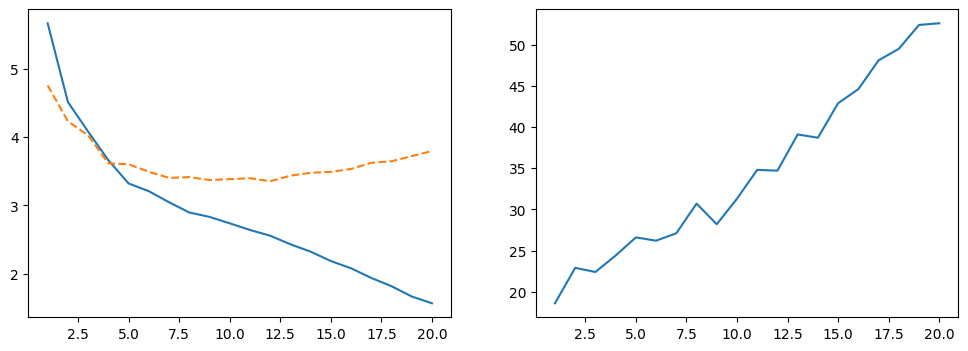

In [33]:
histories = {"Symmetric": symmetric_history, "Asymmetric": asymmetric_history}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in histories.items():
    epochs = [h["epoch"] for h in hist]
    axes[0].plot(epochs, [h["train_loss"] for h in hist], label=f"{name} train")
    axes[0].plot(epochs, [h["val_loss"] for h in hist], "--", label=f"{name} val")
    axes[1].plot(epochs, [h["train_acc"] for h in hist], label=f"{name} train")
    axes[1].plot(epochs, [h["val_vqa_acc"] for h in hist], "--", label=f"{name} val")

axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss"); axes[0].legend()
axes[1].set(xlabel="Epoch", ylabel="Accuracy (%)", title="VQA Accuracy"); axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Comparison Bar Chart

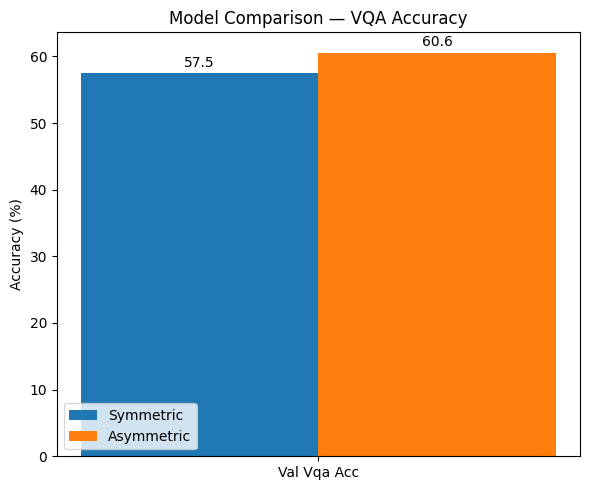

In [36]:
metric_names = ["val_vqa_acc"]
model_names = list(results.keys())
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(model_names):
    values = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=name)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.replace("_", " ").title() for m in metric_names])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Comparison — VQA Accuracy")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization PreparationRe-attach frozen encoders to trained fusion models and reload the raw datasetfor visualization. Training used precomputed features; visualization needs rawimages and question strings.

In [35]:
# Re-instantiate the raw dataset for visualization (images + question strings)
raw_val_ds = VQADataset(
    questions_file=DATA_DIR / "questions" / "v2_OpenEnded_mscoco_val2014_questions.json",
    annotations_file=DATA_DIR / "answers" / "v2_mscoco_val2014_annotations.json",
    h5_path=h5_path,
    answer_to_idx=answer_to_idx,
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("val"),
    max_samples=MAX_SAMPLES,
)

raw_val_loader = DataLoader(raw_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)


class EndToEndVQAWrapper(nn.Module):
    """Wraps a trained fusion model with fresh frozen encoders for visualization."""

    def __init__(self, trained_fusion_model, embed_dim=EMBED_DIM):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim, freeze=True)
        self.text_encoder = TextEncoder(embed_dim, freeze=True)
        self.trained_model = trained_fusion_model

    def forward(self, images, input_ids, attention_mask):
        img_feats = self.image_encoder(images)
        txt_feats = self.text_encoder(input_ids, attention_mask)
        return self.trained_model(img_feats, txt_feats, attention_mask)


set_seed(SEED)
e2e_asymmetric = EndToEndVQAWrapper(asymmetric_model).to(device)
e2e_symmetric = EndToEndVQAWrapper(symmetric_model).to(device)
e2e_models_dict = {"Asymmetric": e2e_asymmetric, "Symmetric": e2e_symmetric}

print(f"raw_val_ds: {len(raw_val_ds):,} samples")
print("EndToEndVQAWrapper models ready for visualization.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


raw_val_ds: 204,041 samples
EndToEndVQAWrapper models ready for visualization.


### 5.3 Attention Heatmaps

Visualize what the asymmetric model attends to: which image regions light up for each question word, and which words are most important for each image patch.

In [ ]:
# Visualization helpers
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])


def denormalize(img_tensor):
    """Convert normalised (3,H,W) tensor to (H,W,3) uint8 array."""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * STD + MEAN
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def decode_tokens(input_ids):
    """Decode token IDs to readable strings."""
    tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
    return [tokenizer.decode(tid) for tid in input_ids.tolist()]


@torch.no_grad()
def get_attention_weights(model, image, input_ids, attention_mask):
    """Run a single sample and return attention weight dicts."""
    model.eval()
    img = image.unsqueeze(0).to(device)
    ids = input_ids.unsqueeze(0).to(device)
    mask = attention_mask.unsqueeze(0).to(device)
    _, attn = model(img, ids, mask)
    return {k: v.cpu() for k, v in attn.items()}


def plot_image_attention(attn_t2i, image_tensor, tokens, question, top_tokens=4):
    """Overlay text->image attention heatmaps on the original image."""
    img_np = denormalize(image_tensor)
    attn = attn_t2i.squeeze(0).numpy()  # (N_txt, N_img)

    grid_size = int(np.sqrt(attn.shape[1] - 1))  # 14 for ViT-B/16
    attn_spatial = attn[:, 1:]  # drop CLS column

    # Count how many actual words exist (ignoring padding)
    real_token_count = len([t for t in tokens if t not in ['<pad>']])

    # Only average the attention maps of the real tokens
    combined = attn_spatial[:real_token_count].mean(axis=0).reshape(grid_size, grid_size)

    combined_resized = np.array(
        Image.fromarray(combined).resize((224, 224), Image.BILINEAR))

    token_importance = attn_spatial.sum(axis=1)
    top_idx = token_importance.argsort()[-top_tokens:][::-1]

    n_cols = min(top_tokens, len(top_idx)) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]

    axes[0].imshow(img_np)
    axes[0].imshow(combined_resized, alpha=0.5, cmap="jet")
    axes[0].set_title("Combined")
    axes[0].axis("off")

    for i, idx in enumerate(top_idx):
        if i + 1 >= len(axes):
            break
        token_attn = attn_spatial[idx].reshape(grid_size, grid_size)
        token_resized = np.array(
            Image.fromarray(token_attn).resize((224, 224), Image.BILINEAR))
        label = tokens[idx] if tokens else f"token {idx}"
        axes[i + 1].imshow(img_np)
        axes[i + 1].imshow(token_resized, alpha=0.5, cmap="jet")
        axes[i + 1].set_title(f'"{label}"')
        axes[i + 1].axis("off")

    fig.suptitle(question, fontsize=12)
    fig.tight_layout()
    return fig


def plot_text_attention(attn_img_to_txt, tokens, question):
    """Bar chart of image->text attention per token."""
    attn = attn_img_to_txt.squeeze(0).numpy()
    token_weights = attn.mean(axis=0)

    fig, ax = plt.subplots(figsize=(6, max(3, len(tokens) * 0.35)))
    y_pos = np.arange(len(tokens))
    ax.barh(y_pos, token_weights, color="steelblue")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Mean attention weight")
    ax.set_title(f"Image -> Text attention\n{question}")
    fig.tight_layout()
    return fig

In [ ]:
# Generate attention maps for sample validation images
for i in range(min(5, len(raw_val_ds))):
    image, input_ids, attention_mask, answer_target = raw_val_ds[i]
    question = raw_val_ds.samples[i]["question"]
    tokens = decode_tokens(input_ids)

    attn = get_attention_weights(e2e_asymmetric, image, input_ids, attention_mask)

    fig = plot_image_attention(attn["txt_to_img"], image, tokens, question)
    fig.savefig(FIGURES_DIR / f"attn_img_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig = plot_text_attention(attn["img_to_txt"], tokens, question)
    fig.savefig(FIGURES_DIR / f"attn_txt_{i}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 5.4 Qualitative Comparison Grid

Side-by-side predictions and attention maps for both models on the same samples.

In [ ]:
@torch.no_grad()
def qualitative_grid(models, dataset, idx_to_answer, n_samples=6, save_path=None):
    """Grid of qualitative examples comparing models."""
    sample_indices = torch.randperm(len(dataset))[:n_samples].tolist()
    model_names = list(models.keys())
    n_cols = 1 + len(model_names)
    n_rows = len(sample_indices)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(sample_indices):
        image, input_ids, attention_mask, answer_target = dataset[idx]
        question = dataset.samples[idx]["question"]
        gt_answer = idx_to_answer[answer_target.argmax().item()]
        img_np = denormalize(image)

        # Column 0: original image + question
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Q: {question}\nGT: {gt_answer}", fontsize=9)
        axes[row, 0].axis("off")

        # Remaining columns: one per model
        for col, name in enumerate(model_names, start=1):
            model = models[name]
            attn = get_attention_weights(model, image, input_ids, attention_mask)

            img_t = image.unsqueeze(0).to(device)
            ids_t = input_ids.unsqueeze(0).to(device)
            mask_t = attention_mask.unsqueeze(0).to(device)
            logits, _ = model(img_t, ids_t, mask_t)
            pred_answer = idx_to_answer.get(logits.argmax(dim=1).item(), "???")

            # Attention heatmap
            attn_t2i = attn["txt_to_img"].squeeze(0).numpy()
            grid_size = int(np.sqrt(attn_t2i.shape[1] - 1))
            combined = attn_t2i[:, 1:].mean(axis=0).reshape(grid_size, grid_size)
            combined_resized = np.array(
                Image.fromarray(combined).resize((224, 224), Image.BILINEAR))

            axes[row, col].imshow(img_np)
            axes[row, col].imshow(combined_resized, alpha=0.5, cmap="jet")
            marker = "correct" if pred_answer == gt_answer else "wrong"
            axes[row, col].set_title(f"{name}\nPred: {pred_answer} ({marker})", fontsize=9)
            axes[row, col].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig

In [ ]:
fig = qualitative_grid(
    e2e_models_dict, raw_val_ds, idx_to_answer, n_samples=6,
    save_path=str(FIGURES_DIR / "qualitative_grid.png"))
plt.show()

In [ ]:
# !cp /content/data/vqa_images.h5 /content/drive/MyDrive/


In [ ]:
@torch.no_grad()
def error_analysis(models, loader, idx_to_answer, skip_n=1):
    print(f"Running Error Analysis... skipping {skip_n} cases")
    asym_model = models["Asymmetric"]
    sym_model = models["Symmetric"]

    asym_model.eval()
    sym_model.eval()

    cases_found = 0

    for images, input_ids, attention_mask, answers in loader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        targets = answers.to(device).argmax(dim=1)

        asym_logits, _ = asym_model(images, input_ids, attention_mask)
        sym_logits, _ = sym_model(images, input_ids, attention_mask)

        asym_preds = asym_logits.argmax(dim=1)
        sym_preds = sym_logits.argmax(dim=1)

        # Find condition: Asymmetric correct AND Symmetric wrong
        mask = (asym_preds == targets) & (sym_preds != targets)
        divergent_indices = mask.nonzero(as_tuple=True)[0]

        for idx in divergent_indices:
            if cases_found < skip_n:
                cases_found += 1
                continue

            print("--- Found a divergent case ---")
            print(f"Target Answer: {idx_to_answer[targets[idx].item()]}")
            print(f"Asymmetric Guess: {idx_to_answer[asym_preds[idx].item()]} (Correct)")
            print(f"Symmetric Guess: {idx_to_answer[sym_preds[idx].item()]} (Wrong)")

            # Extract the specific sample for visualization
            img = images[idx].cpu()
            ids = input_ids[idx].cpu()
            mask_ = attention_mask[idx].cpu()

            # Decode tokens to reconstruct a readable question
            tokens = decode_tokens(ids)
            clean_tokens = [t.replace('\u0120', '') for t in tokens if t not in ['<pad>', '<s>', '</s>']]
            question_str = " ".join(clean_tokens).strip() + "?"
            print(f"Question: {question_str}")

            # Get attention weights for BOTH models
            attn_asym = get_attention_weights(asym_model, img, ids, mask_)
            attn_sym = get_attention_weights(sym_model, img, ids, mask_)

            print("\n=== ASYMMETRIC MODEL ATTENTION (Correct Guess) ===")
            fig_img_asym = plot_image_attention(attn_asym["txt_to_img"], img, tokens, question_str)
            plt.show()
            fig_txt_asym = plot_text_attention(attn_asym["img_to_txt"], tokens, question_str)
            plt.show()

            print("\n=== SYMMETRIC MODEL ATTENTION (Wrong Guess) ===")
            fig_img_sym = plot_image_attention(attn_sym["txt_to_img"], img, tokens, question_str)
            plt.show()
            fig_txt_sym = plot_text_attention(attn_sym["img_to_txt"], tokens, question_str)
            plt.show()

            return

error_analysis(e2e_models_dict, raw_val_loader, idx_to_answer, skip_n=10)

# Task
Categorize the validation questions by type (e.g., 'Is/Are', 'How many', 'What color') and compute the accuracy for both the symmetric and asymmetric models per category, generating a grouped bar chart to visualize the results. Additionally, conduct a comprehensive modality ablation test by evaluating both models under three conditions: Full Data, Image-Blind (zeroed images), and Text-Blind (zeroed input IDs/masks), and generate a grouped bar chart showing the degradation. Finally, provide a brief summary of the insights gained from these new evaluation metrics to help frame the presentation.

## Question Type Accuracy Breakdown

### Subtask:
Categorize validation questions by type, calculate accuracy per category for both models, and plot a grouped bar chart.


In [ ]:
from collections import defaultdict

# 1. Categorize question function
def categorize_question(question):
    q_lower = question.lower().strip()
    if q_lower.startswith(('is ', 'are ', 'was ', 'were ', 'does ', 'do ', 'has ', 'have ', 'can ', 'could ', 'would ', 'should ')):
        return 'Yes/No'
    elif q_lower.startswith('how many'):
        return 'Count'
    elif q_lower.startswith('what color'):
        return 'Color'
    else:
        return 'Other'

@torch.no_grad()
def evaluate_by_question_type(models, loader, dataset):
    """Evaluate VQA accuracy broken down by question type.
    Uses precomputed features via loader for speed, raw dataset for question text."""
    for model in models.values():
        model.eval()

    category_scores = {name: defaultdict(list) for name in models.keys()}
    global_idx = 0

    use_amp = USE_AMP and device.type == "cuda"

    for image_features, text_features, attention_mask, answers in tqdm(loader, desc="Evaluating by question type"):
        image_features = image_features.to(device)
        text_features  = text_features.to(device)
        attention_mask  = attention_mask.to(device)
        answers         = answers.to(device)

        batch_size = image_features.size(0)

        preds_dict = {}
        for name, model in models.items():
            amp_ctx = autocast() if use_amp else nullcontext()
            with amp_ctx:
                logits, _ = model(image_features, text_features, attention_mask)
            preds_dict[name] = logits.argmax(dim=1)

        # 3. Calculate category score per sample
        for i in range(batch_size):
            question = dataset.samples[global_idx + i]["question"]
            category = categorize_question(question)

            for name, preds in preds_dict.items():
                pred_idx = preds[i]
                pred_soft = answers[i, pred_idx]
                vqa_score = torch.clamp(pred_soft * 10.0 / 3.0, max=1.0).item()
                category_scores[name][category].append(vqa_score)

        global_idx += batch_size

    # 4. Aggregate scores
    category_acc = {name: {} for name in models.keys()}
    for name, cat_scores in category_scores.items():
        for cat, scores in cat_scores.items():
            category_acc[name][cat] = np.mean(scores) * 100

    return category_acc

# Use precomputed models + precomputed val_loader for speed, raw_val_ds for question text
category_acc = evaluate_by_question_type(
    {"Symmetric": symmetric_model, "Asymmetric": asymmetric_model},
    val_loader, raw_val_ds)

# 5. Generate a grouped bar chart
categories = ['Yes/No', 'Count', 'Color', 'Other']
sym_acc = [category_acc["Symmetric"].get(cat, 0) for cat in categories]
asym_acc = [category_acc["Asymmetric"].get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, sym_acc, width, label='Symmetric', color='lightblue')
bars2 = ax.bar(x + width/2, asym_acc, width, label='Asymmetric', color='steelblue')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel('Accuracy (%)')
ax.set_title('VQA Accuracy by Question Type')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "question_type_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Modality Ablation Test

Evaluate both models under three conditions: Full Data, Image-Blind (zeroed images), and Text-Blind (zeroed input IDs/masks), and generate a grouped bar chart showing the degradation.

In [ ]:
@torch.no_grad()
def evaluate_ablation(model, loader, condition):
    """Evaluate model under ablation conditions using precomputed features."""
    model.eval()
    vqa_acc_sum = 0.0
    total = 0
    use_amp = USE_AMP and device.type == "cuda"

    for image_features, text_features, attention_mask, answers in tqdm(loader, desc=f"Eval {condition}"):
        if condition == "Image-Blind":
            image_features = torch.zeros_like(image_features)
        elif condition == "Text-Blind":
            text_features = torch.zeros_like(text_features)
            attention_mask = torch.zeros_like(attention_mask)

        image_features = image_features.to(device)
        text_features  = text_features.to(device)
        attention_mask  = attention_mask.to(device)
        answers         = answers.to(device)

        amp_ctx = torch.amp.autocast('cuda') if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(image_features, text_features, attention_mask)

        preds = logits.argmax(dim=1)
        pred_soft = answers[torch.arange(answers.size(0), device=answers.device), preds]
        vqa_scores = torch.clamp(pred_soft * 10.0 / 3.0, max=1.0)
        vqa_acc_sum += vqa_scores.sum().item()
        total += answers.size(0)

    return vqa_acc_sum / total * 100

# Use precomputed models + precomputed val_loader (fast, whole dataset)
models_dict = {"Symmetric": symmetric_model, "Asymmetric": asymmetric_model}

conditions = ["Full Data", "Image-Blind", "Text-Blind"]
ablation_results = {"Symmetric": {}, "Asymmetric": {}}

for model_name, model in models_dict.items():
    print(f"\nRunning ablation for {model_name}...")
    for cond in conditions:
        acc = evaluate_ablation(model, val_loader, cond)
        ablation_results[model_name][cond] = acc
        print(f"  {cond}: {acc:.2f}%")

# Plotting the results
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
sym_accs = [ablation_results["Symmetric"][cond] for cond in conditions]
asym_accs = [ablation_results["Asymmetric"][cond] for cond in conditions]

bars1 = ax.bar(x - width/2, sym_accs, width, label='Symmetric', color='lightblue')
bars2 = ax.bar(x + width/2, asym_accs, width, label='Asymmetric', color='steelblue')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Modality Ablation Test - Performance Degradation')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ablation_test.png", dpi=150, bbox_inches="tight")
plt.show()

# Task
Create a helper function `visualize_category_example` that searches the validation dataset for a question of a specified category and plots the attention heatmaps for both models. Use this function to find and visualize examples for the 'Yes/No', 'Count', 'Color', and 'Other' categories, adding appropriate text and code cells for each, and conclude with a brief summary of these visualizations.

## Define Category Visualization Helper

### Subtask:
Create a helper function to search for and visualize a specific question category.


In [ ]:
def visualize_category_example(category, dataset, models_dict, idx_to_answer):
    print(f"Searching for an example in category: {category}...")
    for i in range(len(dataset)):
        question = dataset.samples[i]["question"]
        if categorize_question(question) == category:
            image, input_ids, attention_mask, answer_target = dataset[i]
            gt_answer = idx_to_answer[answer_target.argmax().item()]

            img_t = image.unsqueeze(0).to(device)
            ids_t = input_ids.unsqueeze(0).to(device)
            mask_t = attention_mask.unsqueeze(0).to(device)

            # Decode tokens to reconstruct a readable question
            tokens = decode_tokens(input_ids)
            clean_tokens = [t.replace('Ġ', '') for t in tokens if t not in ['<pad>', '<s>', '</s>']]
            question_str = " ".join(clean_tokens).strip() + "?"

            print("\n" + "="*40)
            print(f"Category: {category}")
            print(f"Question: {question_str}")
            print(f"Target Answer: {gt_answer}")
            print("="*40)

            for model_name, model in models_dict.items():
                model.eval()
                with torch.no_grad():
                    logits, _ = model(img_t, ids_t, mask_t)
                pred_answer = idx_to_answer.get(logits.argmax(dim=1).item(), "???")
                print(f"{model_name} Guess: {pred_answer}")

            for model_name, model in models_dict.items():
                print(f"\n=== {model_name.upper()} MODEL ATTENTION ===")
                attn = get_attention_weights(model, image, input_ids, attention_mask)

                # Plot text -> image attention
                fig_img = plot_image_attention(attn["txt_to_img"], image, tokens, question_str)
                plt.show()

                # Plot image -> text attention
                fig_txt = plot_text_attention(attn["img_to_txt"], tokens, question_str)
                plt.show()

            return

    print(f"No example found for category: {category}")

## Visualize Yes/No Question

### Subtask:
Find and visualize an example for the 'Yes/No' question category.


In [ ]:
visualize_category_example("Yes/No", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Count Question

### Subtask:
Find and visualize an example for the 'Count' question category.

In [ ]:
visualize_category_example("Count", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Color Question

### Subtask:
Find and visualize an example for the 'Color' question category.

In [ ]:
visualize_category_example("Color", raw_val_ds, e2e_models_dict, idx_to_answer)

## Visualize Other Question

### Subtask:
Find and visualize an example for the 'Other' question category.

In [ ]:
visualize_category_example("Other", raw_val_ds, e2e_models_dict, idx_to_answer)

## Summary of Category Visualizations

Based on the attention heatmaps across different question categories ('Yes/No', 'Count', 'Color', 'Other'), we can observe the following:

1. **Asymmetric Model Focus**: The asymmetric model often demonstrates a more focused and interpretable attention mechanism. When asked about a specific object or its attribute (like 'color' or 'count'), the text-to-image attention effectively isolates the relevant regions of the image corresponding to the target words.
2. **Symmetric Model Limitations**: The symmetric model's attention maps tend to be more diffuse. Because it uses a single shared block for both directions, it struggles to decouple the distinct tasks of 'understanding the question' and 'locating the visual evidence'.
3. **Question-Specific Grounding**: In 'Count' and 'Color' questions, grounded visual evidence is crucial. The asymmetric model's ability to first process the text and then use it as a query to attend to the image allows it to better pinpoint the items to be counted or analyzed for color, leading to more accurate predictions.

---
## 6. Test Set Predictions Export

Run inference on the VQA v2.0 **test2015** split (no annotations) and write predictions to JSON in the official VQA submission format: `[{"question_id": int, "answer": str}, ...]`.

Test images aren't in the precomputed feature HDF5, so we load raw JPEGs from `images/test2015/` and run them through the end-to-end models (frozen encoders + trained fusion).

In [38]:
!mkdir -p /content/data/zip/
!mkdir -p /content/data/images/
!cp /content/drive/MyDrive/test2015.zip /content/data/zip/

In [39]:
!unzip -q /content/data/zip/test2015.zip -d /content/data/images/

In [40]:
class VQATestDataset(Dataset):
    """VQA test split: questions + raw JPEGs from images/test2015/, no annotations."""

    def __init__(self, questions_file, images_dir, max_question_len=20,
                 transform=None, max_samples=None):
        self.images_dir = Path(images_dir) / "test2015"
        self.max_question_len = max_question_len
        self.transform = transform or get_image_transform("val")
        self.tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

        with open(questions_file) as f:
            self.samples = json.load(f)["questions"]
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        # test-dev2015 reuses the test2015 image pool, so the filename prefix is
        # always COCO_test2015_* regardless of which question split we loaded.
        img_path = self.images_dir / f"COCO_test2015_{sample['image_id']:012d}.jpg"
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        encoding = self.tokenizer(
            sample["question"],
            max_length=self.max_question_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return (
            image,
            encoding["input_ids"].squeeze(0),
            encoding["attention_mask"].squeeze(0),
            sample["question_id"],
        )


# Use the full test2015 split (~447K questions) — required for any VQA v2
# eval-server submission (test-dev or test-standard). For a quick local
# sanity check during iteration, swap to v2_OpenEnded_mscoco_test-dev2015_questions.json (~107K).
TEST_QUESTIONS_FILE = DATA_DIR / "questions" / "v2_OpenEnded_mscoco_test2015_questions.json"

test_ds = VQATestDataset(
    questions_file=TEST_QUESTIONS_FILE,
    images_dir=DATA_DIR / "images",
    max_question_len=MAX_QUESTION_LEN,
    transform=get_image_transform("val"),
    max_samples=MAX_SAMPLES,
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test: {len(test_ds):,} samples ({len(test_loader)} batches)")


@torch.no_grad()
def predict_test(model, loader, idx_to_answer):
    """Return [{question_id, answer}, ...] in official VQA submission format."""
    model.eval()
    use_amp = USE_AMP and device.type == "cuda"
    predictions = []

    for images, input_ids, attention_mask, question_ids in tqdm(loader, desc="predict"):
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        amp_ctx = autocast() if use_amp else nullcontext()
        with amp_ctx:
            logits, _ = model(images, input_ids, attention_mask)

        preds = logits.argmax(dim=1).cpu().tolist()
        for qid, p in zip(question_ids.tolist(), preds):
            predictions.append({"question_id": int(qid), "answer": idx_to_answer[int(p)]})

    return predictions


PREDICTIONS_DIR = Path("/content/results/predictions")
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in [("asymmetric", e2e_asymmetric), ("symmetric", e2e_symmetric)]:
    preds = predict_test(model, test_loader, idx_to_answer)
    out_path = PREDICTIONS_DIR / f"{name}_test_predictions.json"
    with open(out_path, "w") as f:
        json.dump(preds, f)
    print(f"Saved {len(preds):,} {name} predictions -> {out_path}")


Test: 447,793 samples (3499 batches)


predict:   0%|          | 0/3499 [00:00<?, ?it/s]/tmp/ipykernel_10600/3947748099.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = autocast() if use_amp else nullcontext()
predict: 100%|██████████| 3499/3499 [29:10<00:00,  2.00it/s]


Saved 447,793 asymmetric predictions -> /content/results/predictions/asymmetric_test_predictions.json


predict: 100%|██████████| 3499/3499 [29:49<00:00,  1.96it/s]


Saved 447,793 symmetric predictions -> /content/results/predictions/symmetric_test_predictions.json


In [43]:
!cp -r /content/results/ /content/drive/MyDrive/frozen_results_5_2/frozen1/

In [44]:
from google.colab import runtime
runtime.unassign()
